In [1]:
import pandas as pd
import numpy as np

events = pd.read_csv("floodevents_indofloods.csv")
rain = pd.read_csv("precipitation_variables_indofloods.csv")
metadata = pd.read_csv("metadata_indofloods.csv")
catchment = pd.read_csv("catchment_characteristics_indofloods.csv")

df = events.merge(rain, on="EventID")

df["EventID"] = df["EventID"].astype(str).str.strip()
df["GaugeID"] = df["EventID"].str.rsplit("-", n=1).str[0]

df = df.merge(metadata, on="GaugeID", how="left")
df = df.merge(catchment, on="GaugeID", how="left")

print("Final merged shape:", df.shape)

Final merged shape: (4548, 148)


In [2]:
important_columns = [
    "T1d","T2d","T3d","T4d","T5d","T6d","T7d","T8d","T9d","T10d",
    "Flood Type",
    "Drainage Area","Catchment Relief","Drainage Density","Ruggedness Number",
    "Latitude","Longitude"
]

df = df[important_columns]

df["Flood Type"] = df["Flood Type"].str.strip()
df["Flood_Label"] = df["Flood Type"].map({
    "Flood": 0,
    "Severe Flood": 1
})

df = df.dropna()

print(df["Flood_Label"].value_counts())

Flood_Label
0    2919
1    1629
Name: count, dtype: int64


In [3]:
# Rain aggregations
df["Rain_3day"] = df["T3d"]
df["Rain_5day"] = df["T5d"]
df["Rain_7day"] = df["T7d"]
df["Rain_10day"] = df["T10d"]

# Ratios & trends
df["Rain_1to3_ratio"] = df["T1d"] / (df["T3d"] + 1e-6)
df["Rain_growth_3to7"] = df["T7d"] - df["T3d"]

# Interactions
df["Rain7_Area"] = df["Rain_7day"] * df["Drainage Area"]
df["Rain7_Rugged"] = df["Rain_7day"] * df["Ruggedness Number"]
df["Rain7_Relief"] = df["Rain_7day"] * df["Catchment Relief"]

# Transformations
df["Log_Drainage_Area"] = np.log1p(df["Drainage Area"])

# Drop raw rainfall
df = df.drop(
    ["T1d","T2d","T3d","T4d","T5d","T6d","T7d","T8d","T9d","T10d"],
    axis=1
)

print("Shape after feature engineering:", df.shape)

Shape after feature engineering: (4548, 18)


In [4]:
from sklearn.model_selection import train_test_split

X = df.drop(["Flood Type", "Flood_Label", "Latitude", "Longitude"], axis=1)
y = df["Flood_Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3638, 14)
Test shape: (910, 14)


In [5]:
from lightgbm import LGBMClassifier

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

model = LGBMClassifier(
    n_estimators=800,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1303, number of negative: 2335
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000794 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2854
[LightGBM] [Info] Number of data points in the train set: 3638, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.358164 -> initscore=-0.583343
[LightGBM] [Info] Start training from score -0.583343
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.03, max_depth=3,
               n_estimators=800, random_state=42,
               scale_pos_weight=1.7920184190330009, subsample=0.8)

In [6]:
y_prob = model.predict_proba(X_test)[:, 1]

threshold = 0.40
y_pred = (y_prob > threshold).astype(int)

In [7]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

print("===== MODEL PERFORMANCE =====\n")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

===== MODEL PERFORMANCE =====

Accuracy : 0.6923076923076923
Precision: 0.5479166666666667
Recall   : 0.8067484662576687
F1 Score : 0.652605459057072
ROC AUC  : 0.8013120850491637

Confusion Matrix:
[[367 217]
 [ 63 263]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.63      0.72       584
           1       0.55      0.81      0.65       326

    accuracy                           0.69       910
   macro avg       0.70      0.72      0.69       910
weighted avg       0.74      0.69      0.70       910



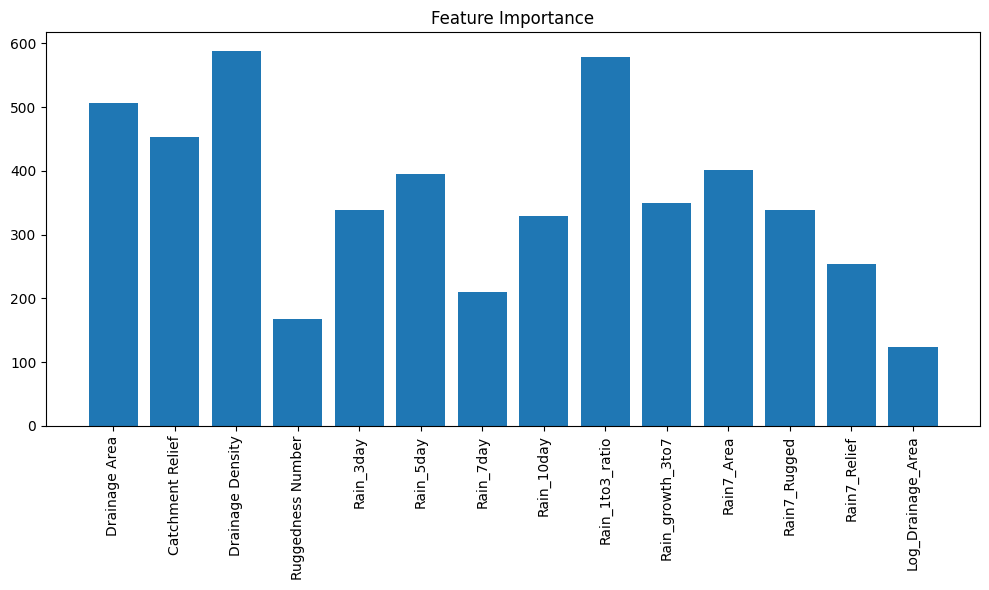

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(X.columns, model.feature_importances_)
plt.xticks(rotation=90)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc, prec, rec, f1 = [], [], [], []

for train_idx, test_idx in skf.split(X, y):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_tr, y_tr)
    y_pr = model.predict(X_te)

    acc.append(accuracy_score(y_te, y_pr))
    prec.append(precision_score(y_te, y_pr))
    rec.append(recall_score(y_te, y_pr))
    f1.append(f1_score(y_te, y_pr))

print("\n===== CROSS VALIDATION =====")
print("Accuracy :", np.mean(acc))
print("Precision:", np.mean(prec))
print("Recall   :", np.mean(rec))
print("F1 Score :", np.mean(f1))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1303, number of negative: 2335
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000617 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2847
[LightGBM] [Info] Number of data points in the train set: 3638, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.358164 -> initscore=-0.583343
[LightGBM] [Info] Start training from score -0.583343
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g